<a href="https://colab.research.google.com/github/akira234mirai/AlineRocha/blob/main/Exploracao%20de%20clientes%20de%20um%20banco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Segmentação de grupos de clientes por meio de dados de compras realizados no cartão de crédito**

In [ ]:
#Importando bibliotecas para exploração da base de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Carregando a base
df = pd.read_csv('CC GENERAL.csv')

# Verificando as primeiras linhas
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
# Renomeando colunas
novos_nomes = ['ID_Cliente', 'saldo', 'atl_saldo', 'qtd_compras', 'max_comp_1', 'parcela_comp', 'vlr_antec', 'Freq_comp', 'Freq_comp_1','freq_comp_parc','freq_vlr_ant', 'qtd_comp_ant', 'qtd_transacao', 'limit_cred', 'valo_pag', 'min_pag', 'perc_pag', 'prazo_cartao']

df.columns = novos_nomes
display(df)

,ID_Cliente,saldo,atl_saldo,qtd_compras,max_comp_1,parcela_comp,vlr_antec,Freq_comp,Freq_comp_1,freq_comp_parc,freq_vlr_ant,qtd_comp_ant,qtd_transacao,limit_cred,valo_pag,min_pag,perc_pag,prazo_cartao
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [ ]:
# Verificando qtd linhas e colunas
print(df.shape)

(8950, 18)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Cliente      8950 non-null   object 
 1   saldo           8950 non-null   float64
 2   atl_saldo       8950 non-null   float64
 3   qtd_compras     8950 non-null   float64
 4   max_comp_1      8950 non-null   float64
 5   parcela_comp    8950 non-null   float64
 6   vlr_antec       8950 non-null   float64
 7   Freq_comp       8950 non-null   float64
 8   Freq_comp_1     8950 non-null   float64
 9   freq_comp_parc  8950 non-null   float64
 10  freq_vlr_ant    8950 non-null   float64
 11  qtd_comp_ant    8950 non-null   int64  
 12  qtd_transacao   8950 non-null   int64  
 13  limit_cred      8949 non-null   float64
 14  valo_pag        8950 non-null   float64
 15  min_pag         8637 non-null   float64
 16  perc_pag        8950 non-null   float64
 17  prazo_cartao    8950 non-null   i

In [ ]:
# Verificando tipos de cada coluna
print(df.dtypes)

ID_Cliente         object
saldo             float64
atl_saldo         float64
qtd_compras       float64
max_comp_1        float64
parcela_comp      float64
vlr_antec         float64
Freq_comp         float64
Freq_comp_1       float64
freq_comp_parc    float64
freq_vlr_ant      float64
qtd_comp_ant        int64
qtd_transacao       int64
limit_cred        float64
valo_pag          float64
min_pag           float64
perc_pag          float64
prazo_cartao        int64
dtype: object


In [ ]:
# Verificando nulos
print(df.isnull().sum())

ID_Cliente          0
saldo               0
atl_saldo           0
qtd_compras         0
max_comp_1          0
parcela_comp        0
vlr_antec           0
Freq_comp           0
Freq_comp_1         0
freq_comp_parc      0
freq_vlr_ant        0
qtd_comp_ant        0
qtd_transacao       0
limit_cred          1
valo_pag            0
min_pag           313
perc_pag            0
prazo_cartao        0
dtype: int64


In [ ]:
# Resumo estatístico da base
display(df.describe())

,saldo,atl_saldo,qtd_compras,max_comp_1,parcela_comp,vlr_antec,Freq_comp,Freq_comp_1,freq_comp_parc,freq_vlr_ant,qtd_comp_ant,qtd_transacao,limit_cred,valo_pag,min_pag,perc_pag,prazo_cartao
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


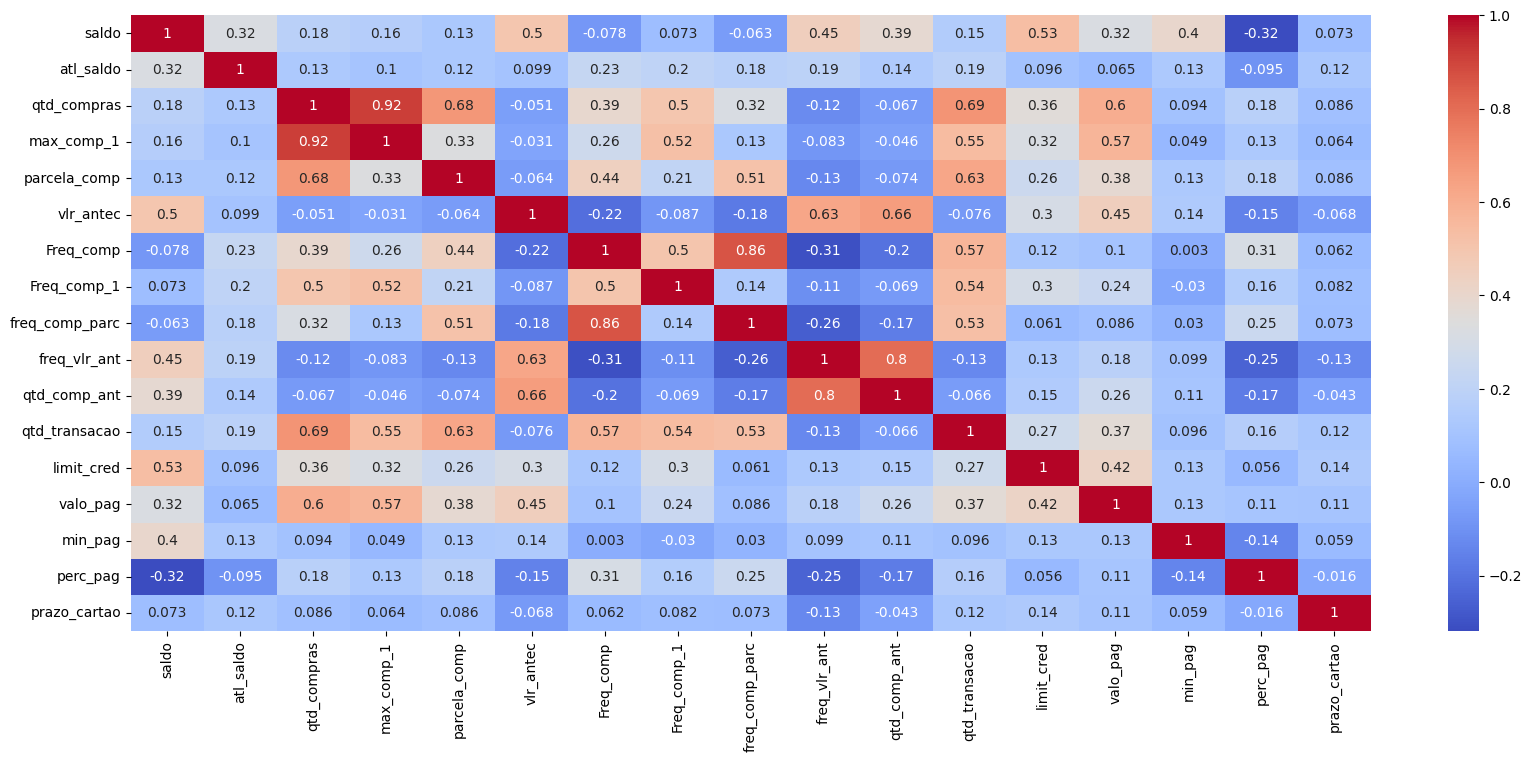

In [ ]:
# Analisando a correlação entre as colunas numéricas
df_numerico = df.select_dtypes(include=[np.number])

plt.figure(figsize=(20, 8))
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm')
plt.show()


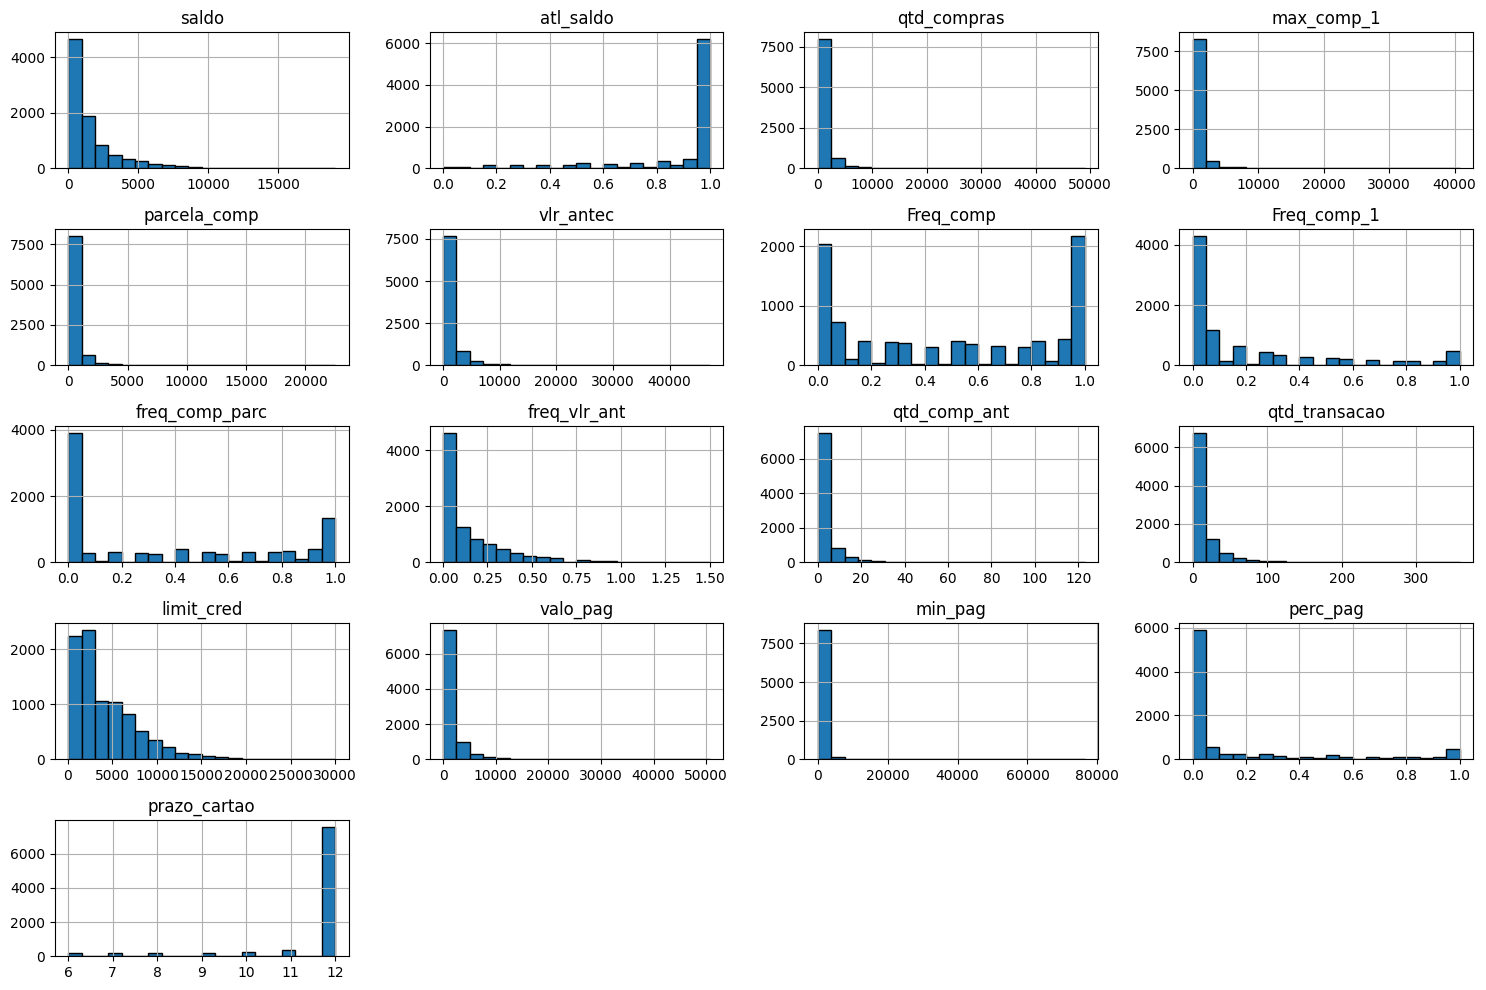

In [ ]:
# Criando histogramas
df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

PRÉ-PROCESSAMENTO

In [ ]:
df.isnull().sum()  # Verifique a quantidade de valores nulos por coluna

,0
ID_Cliente,0
saldo,0
atl_saldo,0
qtd_compras,0
max_comp_1,0
parcela_comp,0
vlr_antec,0
Freq_comp,0
Freq_comp_1,0
freq_comp_parc,0


In [ ]:
#SUBSTITUINDO VALORES NULOS
#Coluna min_page
#Valor substituido na média 'min_pag': 4.878305e-17

#print(df.loc[pd.isnull(df['min_pag'])])


# Substituir valores nulos pela média da coluna 'min_pag'
df['min_pag'].fillna(df['min_pag'].mean(), inplace=True)


#Verificando o valor da média substituida da colula "min_pag"
print(df.loc[df['ID_Cliente'].isin(['C10004','C10047','C10049'])])

#df.isnull().sum()

   ID_Cliente        saldo  atl_saldo  qtd_compras  max_comp_1  parcela_comp  \
3      C10004  1666.670542   0.636364       1499.0      1499.0           0.0   
45     C10047  2242.311686   1.000000        437.0        97.0         340.0   
47     C10049  3910.111237   1.000000          0.0         0.0           0.0   

      vlr_antec  Freq_comp  Freq_comp_1  freq_comp_parc  freq_vlr_ant  \
3    205.788017   0.083333     0.083333        0.000000      0.083333   
45   184.648692   0.333333     0.083333        0.333333      0.166667   
47  1980.873201   0.000000     0.000000        0.000000      0.500000   

    qtd_comp_ant  qtd_transacao  limit_cred  valo_pag     min_pag  perc_pag  \
3              1              1      7500.0       0.0  864.206542       0.0   
45             2              5      2400.0       0.0  864.206542       0.0   
47             7              0      4200.0       0.0  864.206542       0.0   

    prazo_cartao  
3             12  
45            12  
47          

In [ ]:
#SUBSTITUINDO VALORES NULOS
#Coluna limit_cred
#Valor substituido na média 'limit_cred': -0.364644

#print(df.loc[pd.isnull(df['limit_cred'])])

# Substituir valores nulos pela média da coluna 'min_pag'
df['limit_cred'].fillna(df['limit_cred'].mean(), inplace=True)


#Verificando o valor da média substituida da colula "min_pag"
#print(df.loc[df['ID_Cliente'].isin(['C10004','C10047','C10049'])])

#verificando se ainda há valores nulos
df.isnull().sum()

,0
ID_Cliente,0
saldo,0
atl_saldo,0
qtd_compras,0
max_comp_1,0
parcela_comp,0
vlr_antec,0
Freq_comp,0
Freq_comp_1,0
freq_comp_parc,0


In [ ]:
#padronização: colocar media 0 em desvio padrão 1 para evitar problema de sensibilidade da escala de dados do algoritimo (todas as variáveis ​​contribuam de forma equivalente)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['saldo', 'atl_saldo', 'qtd_compras', 'max_comp_1', 'parcela_comp', 'vlr_antec', 'Freq_comp', 'Freq_comp_1','freq_comp_parc','freq_vlr_ant', 'qtd_comp_ant', 'qtd_transacao', 'limit_cred', 'valo_pag', 'min_pag', 'perc_pag', 'prazo_cartao']] = scaler.fit_transform(df[['saldo', 'atl_saldo', 'qtd_compras', 'max_comp_1', 'parcela_comp', 'vlr_antec', 'Freq_comp', 'Freq_comp_1','freq_comp_parc','freq_vlr_ant', 'qtd_comp_ant', 'qtd_transacao', 'limit_cred', 'valo_pag', 'min_pag', 'perc_pag', 'prazo_cartao']])
display(df)

,ID_Cliente,saldo,atl_saldo,qtd_compras,max_comp_1,parcela_comp,vlr_antec,Freq_comp,Freq_comp_1,freq_comp_parc,freq_vlr_ant,qtd_comp_ant,qtd_transacao,limit_cred,valo_pag,min_pag,perc_pag,prazo_cartao
0,C10001,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.360680
1,C10002,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.360680
2,C10003,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.360680
3,C10004,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.360680
4,C10005,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.360680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,-0.737950,0.518084,-0.333293,-0.356934,-0.132643,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960433,-0.486217,-3.498541e-01,1.183951,-4.122768
8946,C19187,-0.742423,0.518084,-0.329136,-0.356934,-0.122823,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960433,-0.503396,4.878305e-17,-0.525551,-4.122768
8947,C19188,-0.740398,-0.185477,-0.401965,-0.356934,-0.294893,-0.466786,0.854576,-0.678661,0.760469,-0.675349,-0.476070,-0.390639,-0.960433,-0.570615,-3.354655e-01,0.329200,-4.122768
8948,C19189,-0.745174,-0.185477,-0.469552,-0.356934,-0.454576,-0.449352,-1.221758,-0.678661,-0.916995,0.157527,-0.182998,-0.591796,-1.097856,-0.580536,-3.469065e-01,0.329200,-4.122768


Outliers identificados nas linhas: [   6   19   20 ... 8947 8948 8949]


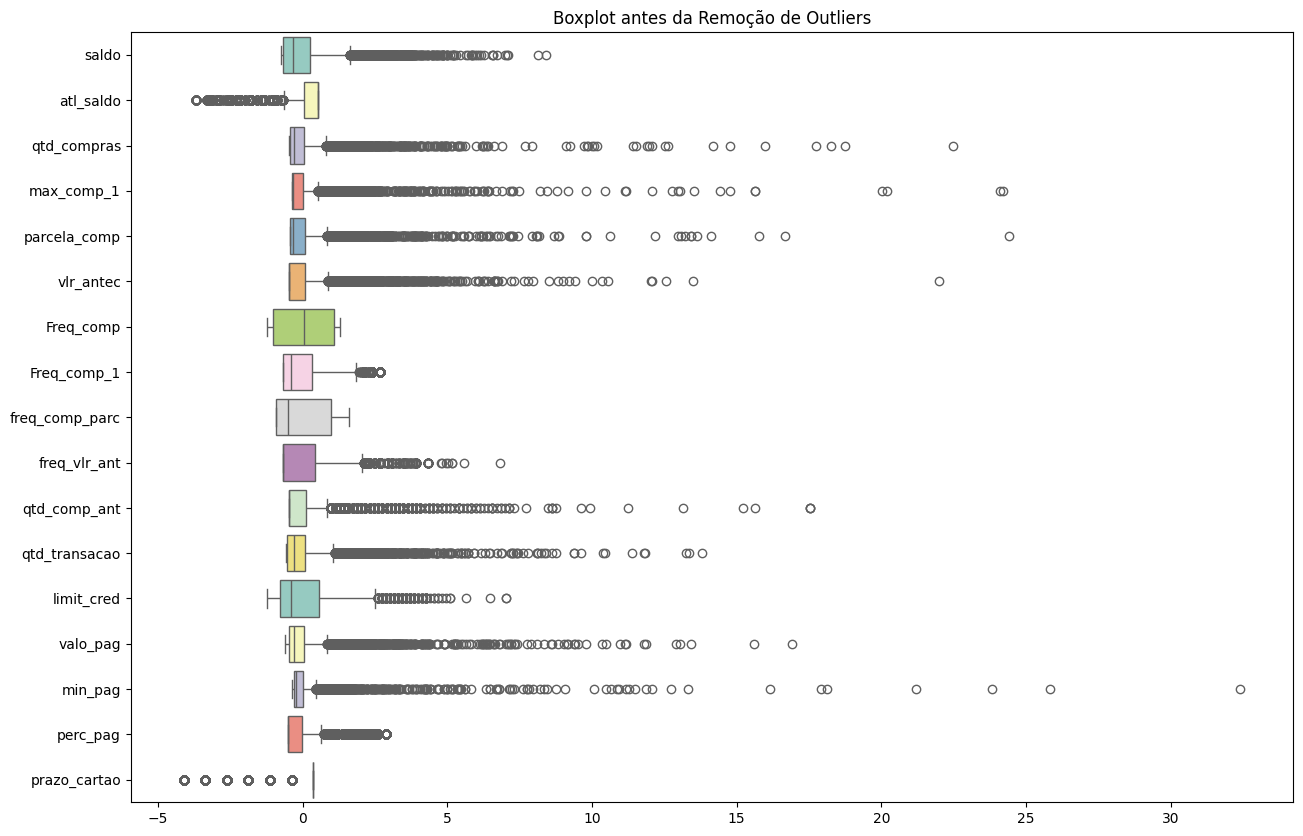

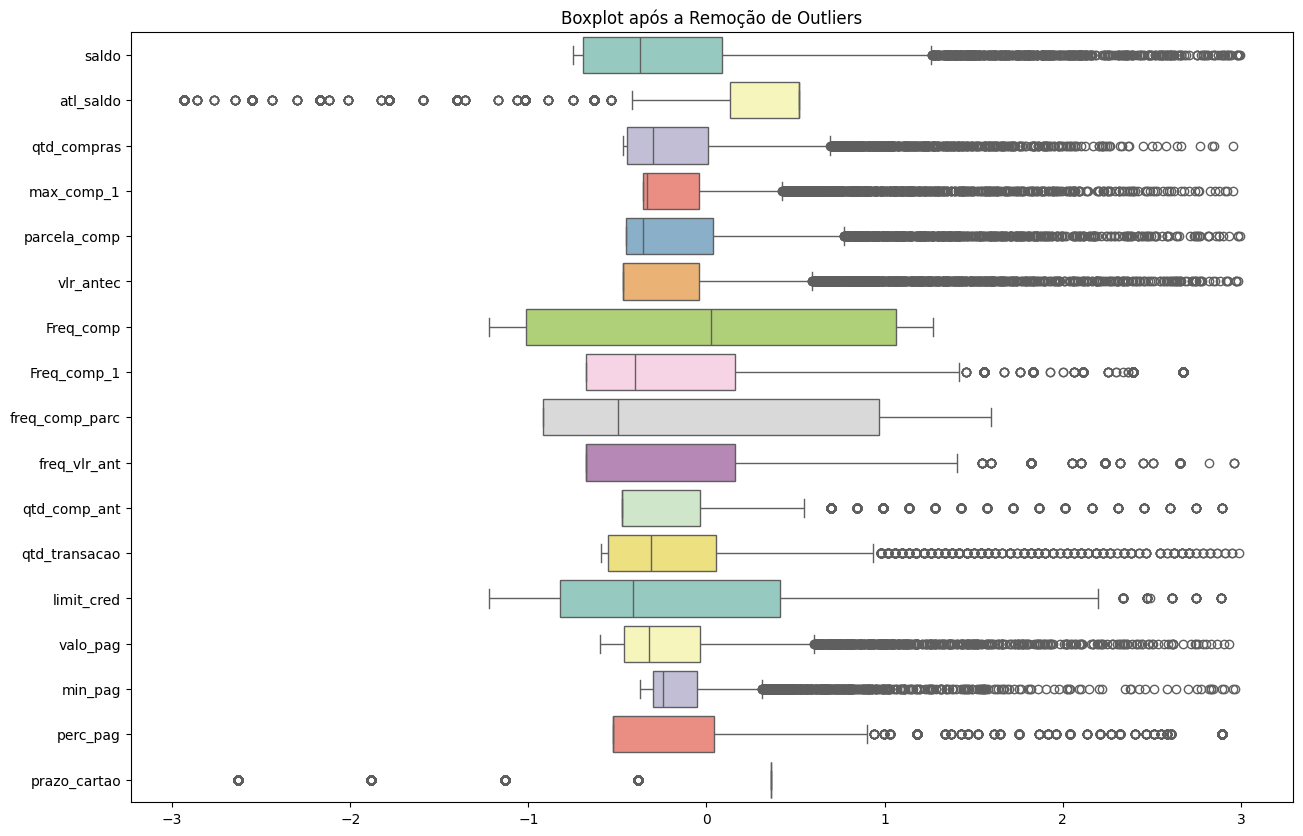

  ID_Cliente     saldo  atl_saldo  qtd_compras  max_comp_1  parcela_comp  \
0     C10001 -0.731989  -0.249434    -0.424900   -0.356934     -0.349079   
1     C10002  0.786961   0.134325    -0.469552   -0.356934     -0.454576   
2     C10003  0.447135   0.518084    -0.107668    0.108889     -0.454576   
3     C10004  0.049099  -1.016953     0.232058    0.546189     -0.454576   
4     C10005 -0.358775   0.518084    -0.462063   -0.347294     -0.454576   

   vlr_antec  Freq_comp  Freq_comp_1  freq_comp_parc  freq_vlr_ant  \
0  -0.466786  -0.806490    -0.678661       -0.707313     -0.675349   
1   2.605605  -1.221758    -0.678661       -0.916995      0.573963   
2  -0.466786   1.269843     2.673451       -0.916995     -0.675349   
3  -0.368653  -1.014125    -0.399319       -0.916995     -0.258913   
4  -0.466786  -1.014125    -0.399319       -0.916995     -0.675349   

   qtd_comp_ant  qtd_transacao  limit_cred  valo_pag       min_pag  perc_pag  \
0     -0.476070      -0.511333   -0.960433

In [ ]:
# Identificando os outliers usando Z-Score
threshold = 3
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))

# Identificar os índices dos outliers
outliers = np.where(z_scores > threshold)
outliers_indices = np.unique(outliers[0])

# Exibir os outliers identificados
print(f"Outliers identificados nas linhas: {outliers_indices}")

# Plotar boxplot antes da remoção dos outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.select_dtypes(include=[np.number]), orient='h', palette='Set3')
plt.title('Boxplot antes da Remoção de Outliers')
plt.show()

# Remover as linhas que contêm outliers
df_cleaned = df.drop(outliers_indices, axis=0)

# Plotar boxplot depois da remoção dos outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_cleaned.select_dtypes(include=[np.number]), orient='h', palette='Set3')
plt.title('Boxplot após a Remoção de Outliers')
plt.show()

# Salvar o novo dataset sem outliers
#df_cleaned.to_csv('/mnt/data/CC_GENERAL_cleaned.csv', index=False)

# Visualizar as primeiras linhas do dataset limpo
print(df_cleaned.head())

### K-MEANS

In [ ]:
#tratamento de dado categorico

import pandas as pd

# Carregar o DataFrame a partir de um arquivo CSV
df = pd.read_csv('CC GENERAL.csv')

# Excluir a coluna 'ID_Cliente' (ou qualquer outra coluna) do DataFrame
df = df.drop(columns=['CUST_ID'])

# Exibir as primeiras linhas para verificar
print(df.head())


       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

### CURVA DO COTOVELO

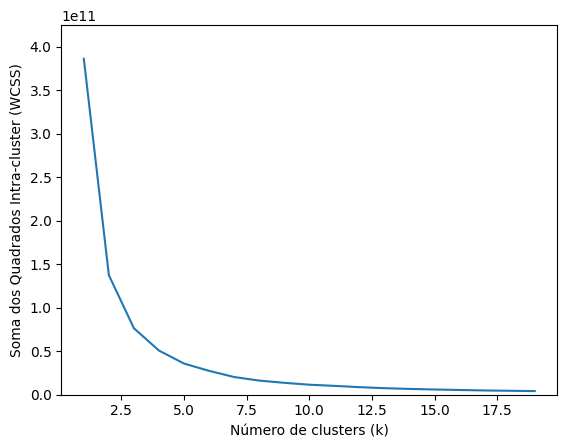

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Remove as linhas que contêm valores ausentes (NaN) em qualquer coluna
df_cleaned = df.dropna()

# Inicializa uma lista para armazenar os valores de inércia
# A inércia é a soma das distâncias quadráticas dos pontos dentro de cada cluster
inertia = []

# Loop para calcular a inércia para diferentes números de clusters, de 1 a 19
for n_clusters in range(1, 20):
    # Executa o KMeans com o número atual de clusters e ajusta aos dados sem valores ausentes
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto').fit(df_cleaned)

    # Armazena a inércia dividida pelo número de clusters, para suavizar os resultados
    inertia.append(kmeans.inertia_ / n_clusters)

# Converte os resultados em um DataFrame para facilitar a visualização
inertias = pd.DataFrame({'n_clusters': range(1, 20), 'inertia': inertia})

# Plota o gráfico de inércia (Elbow Chart) para analisar a melhor quantidade de clusters
ax = inertias.plot(x='n_clusters', y='inertia')

# Define os rótulos dos eixos
plt.xlabel('Número de clusters (k)')
plt.ylabel('Soma dos Quadrados Intra-cluster (WCSS)')

# Define os limites do eixo y para melhorar a visualização
plt.ylim((0, 1.1 * inertias.inertia.max()))

# Remove a legenda do gráfico
ax.legend().set_visible(False)

# Exibe o gráfico
plt.show()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3331.319644,0.946010,1594.941280,998.129167,597.125989,2076.059063,0.547147,0.323439,0.389176,0.209908,5.714599,22.311705,8972.535969,2897.652245,1216.711441,1.416513e-01,11.742657
1,4784.709851,0.913974,10526.108939,7477.575909,3048.699697,5450.978700,0.740347,0.589189,0.594338,0.231315,9.265152,84.098485,12500.378788,17981.423200,2360.279255,3.317512e-01,11.840909
2,877.395002,0.875255,611.891098,315.937316,296.268899,499.598338,0.471978,0.155373,0.355934,0.109212,2.303202,10.831339,2709.447540,1029.307478,537.450111,1.631385e-01,11.448739
3,4411.427484,0.986014,1133.460256,164.097692,969.362564,1055.481567,0.486597,0.047785,0.458236,0.093629,3.025641,21.846154,4644.871795,1600.584280,27017.188279,5.551115e-17,11.897436


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,2.0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,0.0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,0.0
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,2.0
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0.0,8.0,1800.0,1400.057770,2407.246035,0.000000,12.0,0.0


,pca1,pca2,cluster
0,-4391.447490,911.247469,2
1,4044.634211,-2565.160177,0
2,1418.394845,-1924.557181,0
3,-3809.046707,728.326687,2
4,-1966.891227,850.605183,2


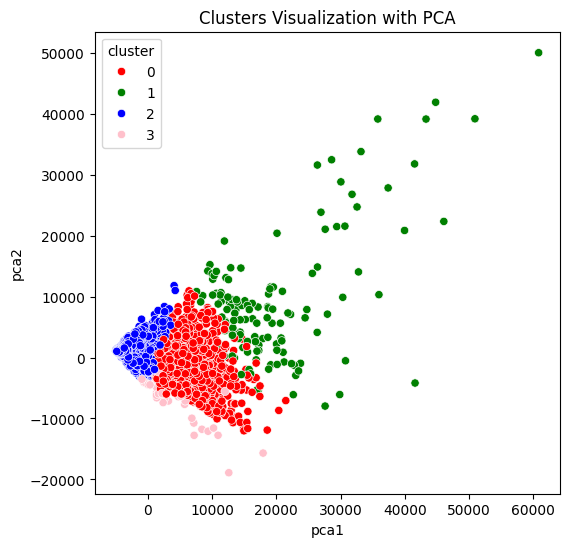

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Número de clusters desejado
optimal_clusters = 4

# Aplicar KMeans ao DataFrame escalado
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0, n_init='auto')
kmeans.fit(df_cleaned)
labels = kmeans.labels_

# Obter os centros dos clusters
cluster_centers = pd.DataFrame(data=kmeans.cluster_centers_, columns=df_cleaned.columns)
display(cluster_centers)

# Adicionar as labels de cluster ao DataFrame original
df_clustered = pd.concat([df_cleaned, pd.DataFrame({'cluster': labels})], axis=1)
display(df_clustered.head())

# Aplicar PCA para reduzir a dimensionalidade para 2 componentes principais
pca = PCA(n_components=2)
principal_comp = pca.fit_transform(df_cleaned)
pca_df = pd.DataFrame(data=principal_comp, columns=['pca1', 'pca2'])

# Adicionar as labels de cluster ao DataFrame de PCA
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis=1)
display(pca_df.head())

# Visualização dos clusters em um gráfico de dispersão baseado nos componentes principais
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=pca_df, palette=['red', 'green', 'blue', 'pink'])
plt.title('Clusters Visualization with PCA')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Calcular o Índice de Silhueta
silhouette_avg = silhouette_score(df_cleaned, labels)
print(f"Índice de Silhueta: {silhouette_avg:.4f}")


Índice de Silhueta: 0.4606


,pca1,pca2,cluster
0,-1856.218223,-641.645418,0
1,4912.238187,-2286.938350,1
2,-67.466009,691.618710,0
3,-1310.614402,-427.484498,0
4,-587.656734,149.639603,0


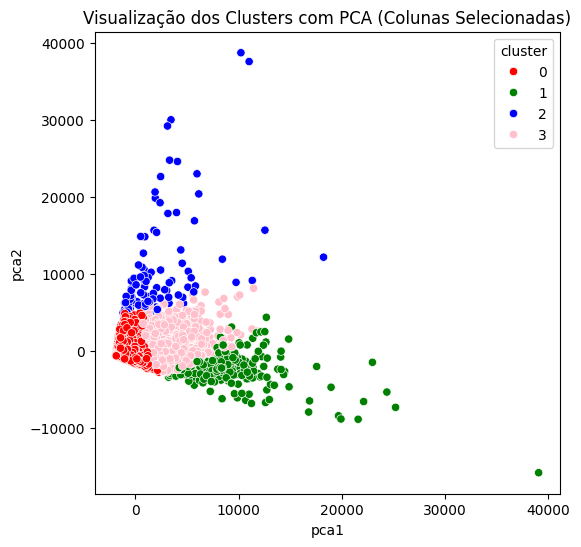

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans # Importar o KMeans

# Selecionar as colunas específicas para aplicar o PCA
pca_columns = ['CASH_ADVANCE', 'ONEOFF_PURCHASES', 'BALANCE', 'INSTALLMENTS_PURCHASES']
df_pca = df_cleaned[pca_columns]

# Aplicar PCA para reduzir a dimensionalidade para 2 componentes principais
pca = PCA(n_components=2)
principal_comp = pca.fit_transform(df_pca)
pca_df = pd.DataFrame(data=principal_comp, columns=['pca1', 'pca2'])

# Executar a clusterização com KMeans para obter os rótulos dos clusters
kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto') # Inicializar o KMeans com o número desejado de clusters
kmeans.fit(df_pca) # Ajustar o KMeans aos dados
labels = kmeans.labels_ # Obter os rótulos dos clusters

# Adicionar os rótulos de cluster ao DataFrame do PCA
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis=1)
display(pca_df.head())

# Visualização dos clusters em um gráfico de dispersão baseado nos componentes principais
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=pca_df, palette=['red', 'green', 'blue', 'pink'])
plt.title('Visualização dos Clusters com PCA (Colunas Selecionadas)')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

# Calcular o Índice de Silhueta
silhouette_avg = silhouette_score(df_cleaned, labels)
print(f"Índice de Silhueta: {silhouette_avg:.4f}")

Índice de Silhueta: 0.3823


<ipython-input-22-34038c00a08f>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['predicted_cluster'] = kmeans.fit_predict(scaled_data)


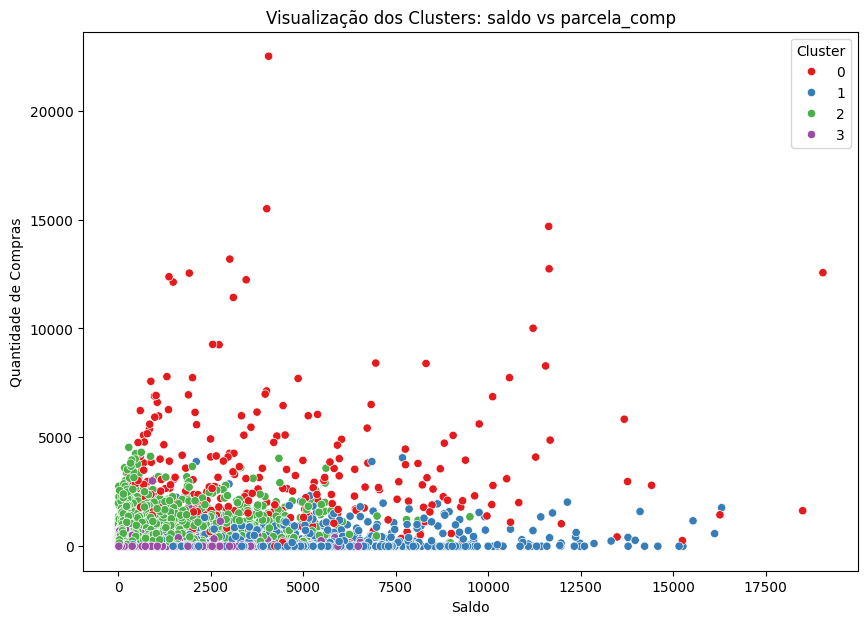

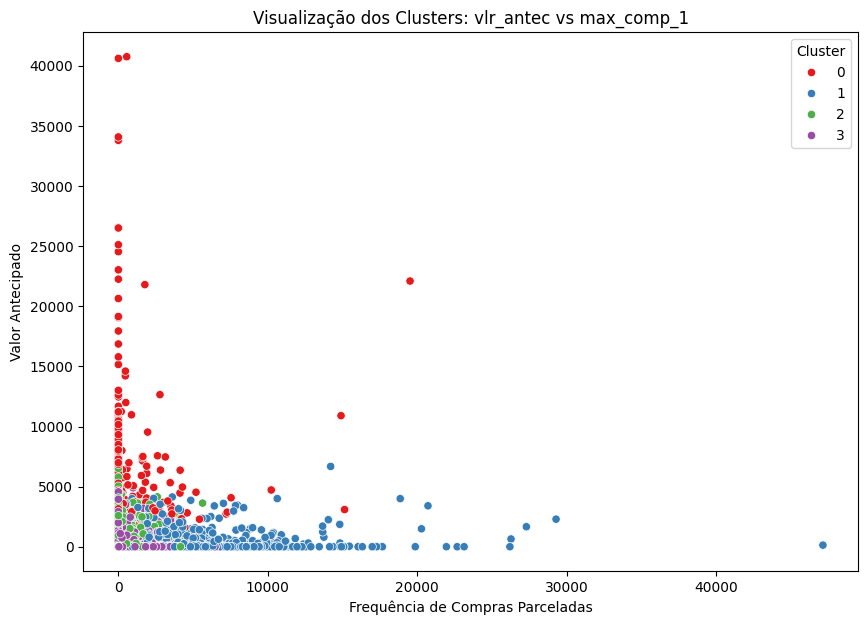

<ipython-input-22-34038c00a08f>:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


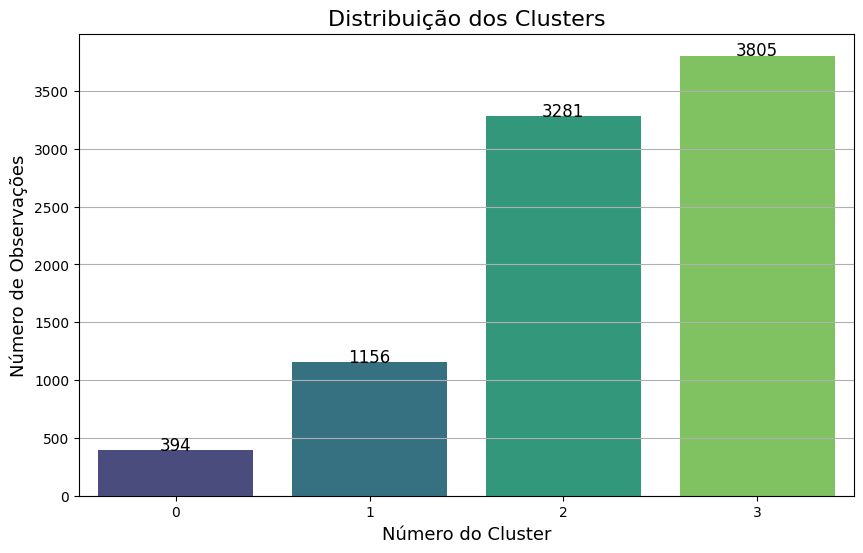

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Defina o número ideal de clusters
optimal_clusters = 4

# Inicialize o StandardScaler
scaler = StandardScaler()

# Ajuste e transforme os dados numéricos do DataFrame
# Selecione apenas as colunas numéricas para escalar
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
scaled_data = scaler.fit_transform(df_cleaned[numeric_cols])

# Aplique o KMeans com o número de clusters escolhido
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0, n_init='auto')
df_cleaned['predicted_cluster'] = kmeans.fit_predict(scaled_data)

# Calcule a acurácia se você tiver rótulos verdadeiros
if 'true_labels' in df_cleaned.columns:
    # Supondo que 'true_labels' contém os rótulos verdadeiros
    from sklearn.metrics import accuracy_score
    true_labels = df_cleaned['true_labels']
    predicted_labels = df_cleaned['predicted_cluster']



# Exemplo de visualização dos clusters em gráficos de dispersão com múltiplas variáveis
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_cleaned['BALANCE'], y=df_cleaned['INSTALLMENTS_PURCHASES'], hue=df_cleaned['predicted_cluster'], palette='Set1')
plt.title('Visualização dos Clusters: saldo vs parcela_comp')
plt.xlabel('Saldo')
plt.ylabel('Quantidade de Compras')
plt.legend(title='Cluster')
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(x=df_cleaned['CASH_ADVANCE'], y=df_cleaned['ONEOFF_PURCHASES'], hue=df_cleaned['predicted_cluster'], palette='Set1')
plt.title('Visualização dos Clusters: vlr_antec vs max_comp_1')
plt.xlabel('Frequência de Compras Parceladas')
plt.ylabel('Valor Antecipado')
plt.legend(title='Cluster')
plt.show()

# Função para plotar a distribuição dos clusters
def plot_cluster_distribution(df, cluster_col='predicted_cluster'):
    # Contar o número de ocorrências em cada cluster
    cluster_counts = df[cluster_col].value_counts().sort_index()

    # Configura o tamanho da figura
    plt.figure(figsize=(10, 6))

    # Criar o gráfico de barras
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')

    # Configurar o título e os rótulos dos eixos
    plt.title('Distribuição dos Clusters', fontsize=16)
    plt.xlabel('Número do Cluster', fontsize=13)
    plt.ylabel('Número de Observações', fontsize=13)

    # Adicionar rótulos de valor acima das barras
    for i, count in enumerate(cluster_counts.values):
        plt.text(i, count + 0.5, str(count), ha='center', fontsize=12)

    # Mostrar o gráfico
    plt.grid(axis='y')
    plt.show()

# Plotar a distribuição dos clusters
plot_cluster_distribution(df_cleaned, cluster_col='predicted_cluster')

# salvar o modelo KMeans para uso futuro
with open('kmeans_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)

A combinação das variáveis saldo, parcela_comp, vlr_antec e max_comp_1 foi escolhida para explorar o comportamento financeiro dos clientes, identificando como eles utilizam saldo, parcelamento e crédito. Essas variáveis ajudam a segmentar os clientes com base em padrões de consumo e uso de crédito.

Os 4 grupos de clientes que podem ser obtidos a partir dessa divisão são:

    Clientes econômicos: baixo saldo, poucas compras parceladas.
    Altos consumidores com uso de crédito: alto saldo e alta frequência de parcelamento.
    Clientes que dependem de crédito: antecipam valores para grandes compras.
    Consumidores moderados: comportamento financeiro equilibrado, com uso misto de crédito e parcelamento.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(scaled_data, df_cleaned['predicted_cluster'])
print(f'Silhouette Score: {silhouette_avg:.3f}')

Silhouette Score: 0.197


métrica que avalia a qualidade dos clusters em uma segmentação. Ele mede o quão bem as amostras estão agrupadas